# ДЗ №1 СУНЦ МГУ - Numpy practice

**Среда:** Python 3.14.7. Локальные модули `functions.py` и `functions_vectorized.py` повторно импортируются при каждом запуске ячейки с решением.


### Туториальные задачи
__(9 баллов)__

Ниже приведены задачи на работу с numpy-массивами. Для каждой из задач нужно привести 2 реализации: одна без использования numpy (cчитайте, что там, где на входе или выходе должны быть numpy array, будут просто списки), а вторая полностью векторизованная (без использования питоновских циклов/map/list comprehension). Невекторизованная реализация каждой из задач оценивается в __0.5 балла__, векторизованная – в __1 балл__.

Реализации без использования векторизации нужно записать в файл functions.py, а векторизованные &mdash; в файл functions_vectorized.py

Для каждой задачи, приведённой ниже сравните скорость работы невекторизованной и векторизованной реализации. С помощью пакета matplotlib постройте графики времени работы в зависимости от размера данных. __Графики должны выглядеть опрятно!__ То есть должны быть подписаны оси, названия графиков, и т.д. Например, ниже представлены хороший и плохой графики:

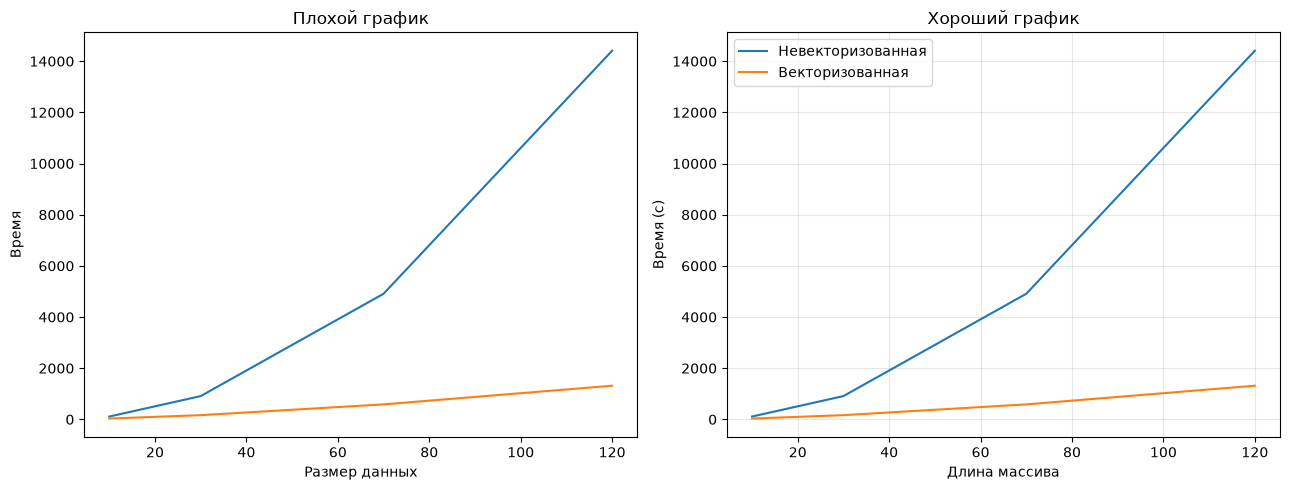

In [1]:
from importlib import reload

import matplotlib.pyplot as plt
import numpy as np
import time

import functions
import functions_vectorized

%matplotlib inline


def reload_solution_modules():
    """Reload the two local solution modules after their files change."""
    reload(functions)
    reload(functions_vectorized)


data_size = np.array([10, 30, 70, 120])
time_non_vectorized = data_size**2 + 10
time_vectorized = data_size**1.5

figure, (axis_bad, axis_good) = plt.subplots(1, 2, figsize=(13, 5))

axis_bad.plot(data_size, time_non_vectorized)
axis_bad.plot(data_size, time_vectorized)
axis_bad.set_title("Плохой график")
axis_bad.set_xlabel("Размер данных")
axis_bad.set_ylabel("Время")

axis_good.plot(data_size, time_non_vectorized, label="Невекторизованная")
axis_good.plot(data_size, time_vectorized, label="Векторизованная")
axis_good.set_title("Хороший график")
axis_good.set_xlabel("Длина массива")
axis_good.set_ylabel("Время (с)")
axis_good.grid(True, alpha=0.3)
axis_good.legend()

figure.tight_layout()
plt.show()


* __Задача 1__: Подсчитать произведение ненулевых элементов на диагонали прямоугольной матрицы.  
 Например, для X = np.array([[1, 0, 1], [2, 0, 2], [3, 0, 3], [4, 4, 4]]) ответ – 3.

TIME: 0.00004
TIME: 0.00010
TIME: 0.00059
TIME: 0.00631
TIME: 0.00004
TIME: 0.00001
TIME: 0.00001
TIME: 0.00007


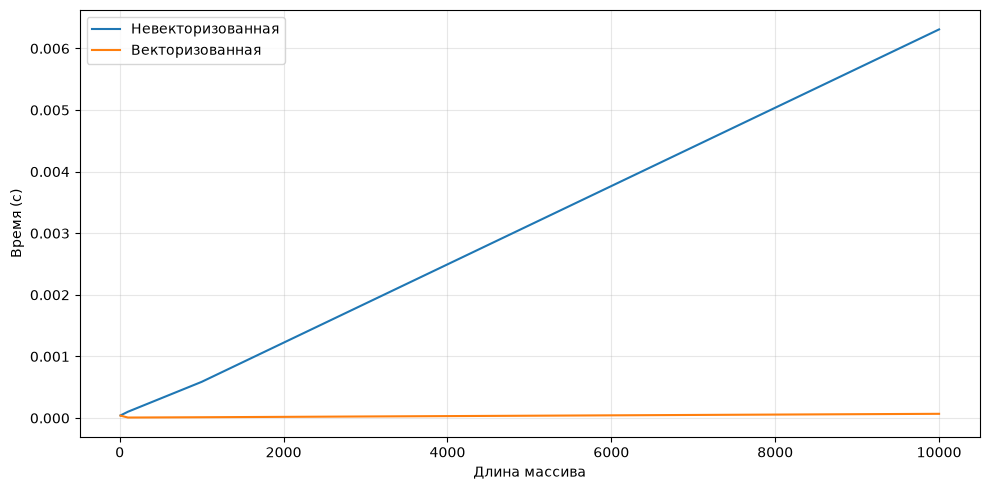

In [5]:
reload_solution_modules()

inp = [
    np.random.randint(1000, size=(10, 10)),
    np.random.randint(1000, size=(100, 100)),
    np.random.randint(1000, size=(1000, 1000)),
    np.random.randint(1000, size=(10000, 10000)),
]

times_common = [
    functions.prod_non_zero_diag(inp[0])[1],
    functions.prod_non_zero_diag(inp[1])[1],
    functions.prod_non_zero_diag(inp[2])[1],
    functions.prod_non_zero_diag(inp[3])[1],
]

times_vectorized = [
    functions_vectorized.prod_non_zero_diag(inp[0])[1],
    functions_vectorized.prod_non_zero_diag(inp[1])[1],
    functions_vectorized.prod_non_zero_diag(inp[2])[1],
    functions_vectorized.prod_non_zero_diag(inp[3])[1],
]

X_axis = [10, 100, 1000, 10000]

figure, axis_good = plt.subplots(1, 1, figsize=(10, 5))

axis_good.plot(X_axis, times_common, label="Невекторизованная")
axis_good.plot(X_axis, times_vectorized, label="Векторизованная")
axis_good.set_xlabel("Длина массива")
axis_good.set_ylabel("Время (с)")
axis_good.grid(True, alpha=0.3)
axis_good.legend()

figure.tight_layout()
plt.show()

 
 
* __Задача 2__: Даны два вектора x и y. Проверить, задают ли они одно и то же мультимножество.  
  Например, для x = np.array([1, 2, 2, 4]), y = np.array([4, 2, 1, 2]) ответ – True.
  
  


TIME: 0.00001
TIME: 0.00006
TIME: 0.00043
TIME: 0.00546
TIME: 0.00007
TIME: 0.00003
TIME: 0.00006
TIME: 0.00049


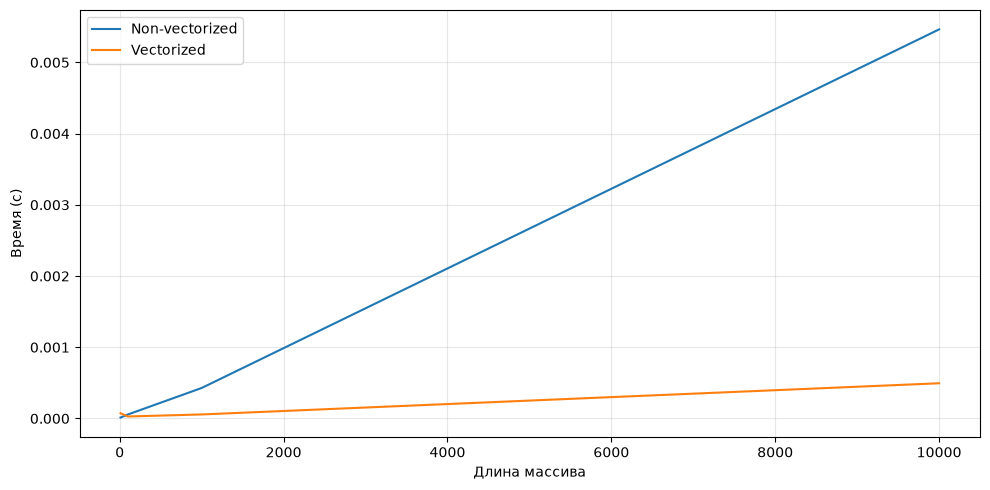

In [10]:
reload_solution_modules()

X = [
    np.random.randint(1000, size=(10)),
    np.random.randint(1000, size=(100)),
    np.random.randint(1000, size=(1000)),
    np.random.randint(1000, size=(10000)),
]

y = [
    np.random.randint(1000, size=(10)),
    np.random.randint(1000, size=(100)),
    np.random.randint(1000, size=(1000)),
    np.random.randint(1000, size=(10000)),
]

com_times = [
    functions.are_multisets_equal(X[0].tolist(), y[0].tolist())[1],
    functions.are_multisets_equal(X[1].tolist(), y[1].tolist())[1],
    functions.are_multisets_equal(X[2].tolist(), y[2].tolist())[1],
    functions.are_multisets_equal(X[3].tolist(), y[3].tolist())[1],
]
vec_times = [
    functions_vectorized.are_multisets_equal(X[0], y[0])[1],
    functions_vectorized.are_multisets_equal(X[1], y[1])[1],
    functions_vectorized.are_multisets_equal(X[2], y[2])[1],
    functions_vectorized.are_multisets_equal(X[3], y[3])[1],
]

X_axis = [10, 100, 1000, 10000]

fig, axs = plt.subplots(1, 1, figsize=(10, 5))
axs.plot(X_axis, com_times, label="Non-vectorized")
axs.plot(X_axis, vec_times, label="Vectorized")
axs.set_xlabel("Длина массива")
axs.set_ylabel("Время (с)")
axs.grid(True, alpha=0.3)
axs.legend()

plt.tight_layout()
plt.show()

* __Задача 3__: Найти максимальный элемент в векторе x среди элементов, перед которыми стоит нулевой.  
 Например, для x = np.array([6, 2, 0, 3, 0, 0, 5, 7, 0]) ответ – 5.

TIME: 0.00003
TIME: 0.00003
TIME: 0.00015
TIME: 0.00281
TIME: 0.00004
TIME: 0.00002
TIME: 0.00003
TIME: 0.00031


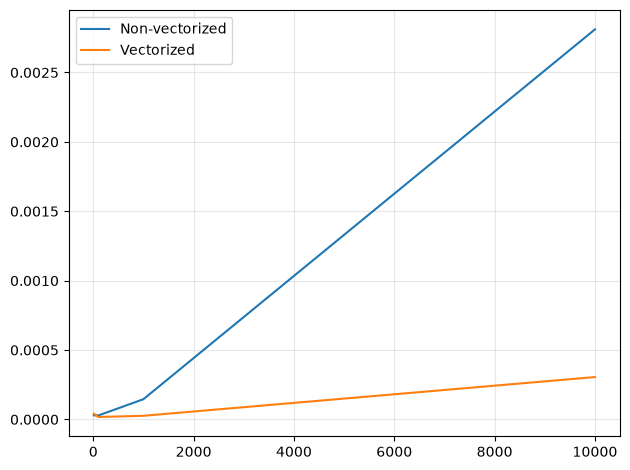

In [18]:
reload_solution_modules()

X_labels = [10, 100, 1000, 10000]

X = [
    np.random.randint(0, 10, size=(10)),
    np.random.randint(0, 10, size=(100)),
    np.random.randint(0, 10, size=(1000)),
    np.random.randint(0, 10, size=(10000)),
]

com_times = [
    functions.max_after_zero(X[0])[1],
    functions.max_after_zero(X[1])[1],
    functions.max_after_zero(X[2])[1],
    functions.max_after_zero(X[3])[1],
]

vec_times = [
    functions_vectorized.max_after_zero(X[0])[1],
    functions_vectorized.max_after_zero(X[1])[1],
    functions_vectorized.max_after_zero(X[2])[1],
    functions_vectorized.max_after_zero(X[3])[1],
]

plt.subplot(1, 1, 1)
plt.plot(X_labels, com_times, label="Non-vectorized")
plt.plot(X_labels, vec_times, label="Vectorized")
# plt.set_xlabel("Длина массива")
# plt.set_ylabel("Время (с)")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

 
 
* __Задача 4__: Дан трёхмерный массив, содержащий изображение, размера (height, width, numChannels), а также вектор длины numChannels. Сложить каналы изображения с указанными весами, и вернуть результат в виде матрицы размера (height, width). В ноутбуке приведите пример работы функции – преобразуйте цветное изображение в оттенки серого, использовав коэффициенты np.array([0.299, 0.587, 0.114]). Считать реальное изображение можно с помощью `PIL.Image.open` из пакета Pillow: `img = np.asarray(Image.open(path).convert("RGB"))`. Устаревшая функция `scipy.misc.imread` удалена из современных версий SciPy.


TIME: 2.20517
TIME: 0.01761
TIME: 3.89427
TIME: 0.03214


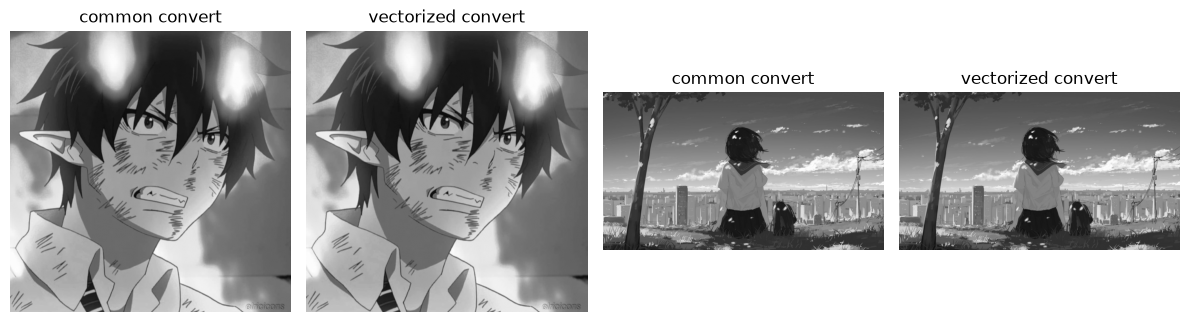

In [19]:
reload_solution_modules()
import PIL
from PIL import Image

image = np.asarray(Image.open('./avatar.jpg').convert("RGB"))
coefs = np.array([0.299, 0.587, 0.114])

common_1 = functions.convert_image(image, coefs)
vectorized_1 = functions_vectorized.convert_image(image, coefs)

image_2 = np.array(Image.open('./wallpapers.jpg').convert("RGB"))

common_2 = functions.convert_image(image_2, coefs)
vectorized_2 = functions_vectorized.convert_image(image_2, coefs)

fig, axes = plt.subplots(1, 4, figsize=(12, 6))

axes[0].imshow(common_1[0], cmap='gray')
axes[0].set_title("common convert")
axes[0].axis('off')

axes[1].imshow(vectorized_1[0], cmap='gray') 
axes[1].set_title("vectorized convert")
axes[1].axis('off')

axes[2].imshow(common_2[0], cmap='gray') 
axes[2].set_title("common convert")
axes[2].axis('off')

axes[3].imshow(vectorized_2[0], cmap='gray') 
axes[3].set_title("vectorized convert")
axes[3].axis('off')

plt.tight_layout()
plt.show()

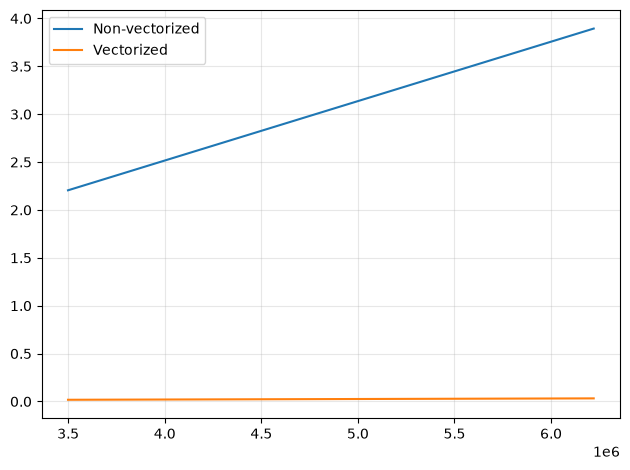

In [22]:
com_times = [
    common_1[1],
    common_2[1],
]

vec_times = [
    vectorized_1[1],
    vectorized_2[1],
]

X_axs = [
    image.size,
    image_2.size,
]

plt.subplot(1, 1, 1)
plt.plot(X_axs, com_times, label="Non-vectorized")
plt.plot(X_axs, vec_times, label="Vectorized")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

* __Задача 5__: Реализовать кодирование длин серий (Run-length encoding). Для некоторого вектора x необходимо вернуть кортеж из двух векторов одинаковой длины. Первый содержит числа, а второй - сколько раз их нужно повторить.  
 Например, для x = np.array([2, 2, 2, 3, 3, 3, 5]) ответ – (np.array([2, 3, 5]), np.array([3, 3, 1])).

TIME: 0.00003
TIME: 0.00010
TIME: 0.00087
TIME: 0.00945
TIME: 0.00012
TIME: 0.00006
TIME: 0.00025
TIME: 0.00017


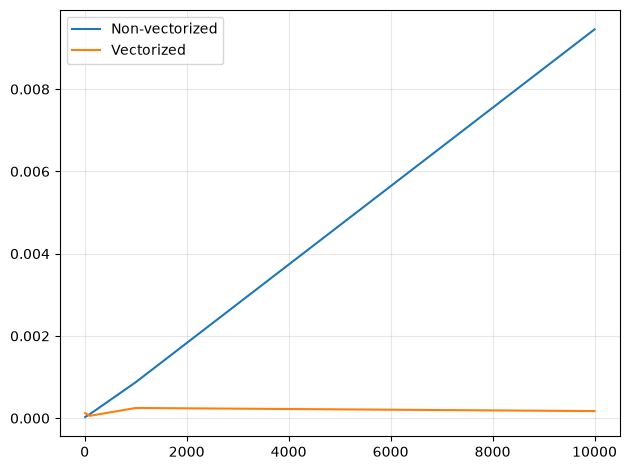

In [26]:
reload_solution_modules()

X = [
    np.random.randint(10, size=(10)),
    np.random.randint(100, size=(100)),
    np.random.randint(1000, size=(1000)),
    np.random.randint(10000, size=(10000)),
]

com_times = [
    functions.run_length_encoding(X[0])[1],
    functions.run_length_encoding(X[1])[1],
    functions.run_length_encoding(X[2])[1],
    functions.run_length_encoding(X[3])[1],
]

vec_times = [
    functions_vectorized.run_length_encoding(X[0])[1],
    functions_vectorized.run_length_encoding(X[1])[1],
    functions_vectorized.run_length_encoding(X[2])[1],
    functions_vectorized.run_length_encoding(X[3])[1],
]

X_axis = [10, 100, 1000, 10000]

plt.subplot(1, 1, 1)
plt.plot(X_axis, com_times, label="Non-vectorized")
plt.plot(X_axis, vec_times, label="Vectorized")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

 
 
* __Задача 6__: Даны две выборки объектов - X и Y. Вычислить матрицу евклидовых расстояний между объектами. Дополнительно сравните с функцией scipy.spatial.distance.cdist по скорости работы (сравнения приведите ниже в ноутбуке).

TIME: 0.00082
TIME: 0.08019
TIME: 0.61440
TIME: 74.89070
TIME: 0.00007
TIME: 0.00045
TIME: 0.00253
TIME: 0.39910


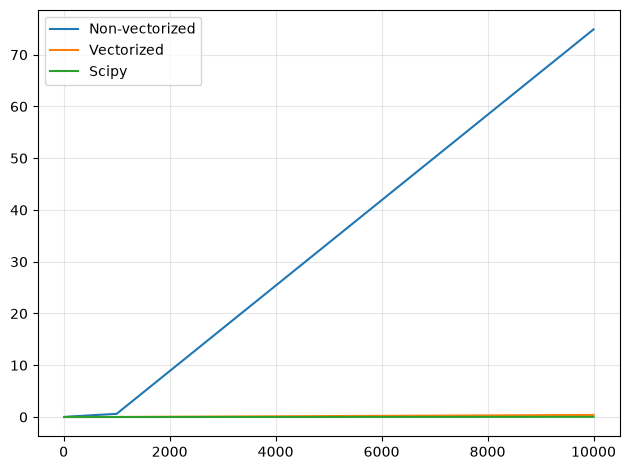

In [31]:
reload_solution_modules()
import scipy
import timeit

X = [
    np.random.randint(10, size=(10, 10)),
    np.random.randint(50, size=(50, 50)),
    np.random.randint(100, size=(100, 100)),
    np.random.randint(500, size=(500, 500)),
]

y = [
    np.random.randint(10, size=(10, 10)),
    np.random.randint(50, size=(50, 50)),
    np.random.randint(100, size=(100, 100)),
    np.random.randint(500, size=(500, 500)),
]

com_times = [
    functions.pairwise_distance(X[0], y[0])[1],
    functions.pairwise_distance(X[1], y[1])[1],
    functions.pairwise_distance(X[2], y[2])[1],
    functions.pairwise_distance(X[3], y[3])[1],
]

vec_times = [
    functions_vectorized.pairwise_distance(X[0], y[0])[1],
    functions_vectorized.pairwise_distance(X[1], y[1])[1],
    functions_vectorized.pairwise_distance(X[2], y[2])[1],
    functions_vectorized.pairwise_distance(X[3], y[3])[1],
]

scipy_times = [
    timeit.timeit(lambda: scipy.spatial.distance.cdist(X[0], y[0]), number=1),
    timeit.timeit(lambda: scipy.spatial.distance.cdist(X[1], y[1]), number=1),
    timeit.timeit(lambda: scipy.spatial.distance.cdist(X[2], y[2]), number=1),
    timeit.timeit(lambda: scipy.spatial.distance.cdist(X[3], y[3]), number=1),
]

X_axis = [10, 100, 1000, 10000]

plt.subplot(1, 1, 1)
plt.plot(X_axis, com_times, label="Non-vectorized")
plt.plot(X_axis, vec_times, label="Vectorized")
plt.plot(X_axis, scipy_times, label="Scipy")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

### Туториал по Markdown

__(1 балл)__

Напишите краткий (а в данной домашке ещё и почти бесмысленный) отчёт с использованием 4-5 различных вариантов разметки/выделения текста.

# *I* ```use``` __Obsidian__ ~~btw~~ *__:3__*

# What
## Level
### Of
#### Header
##### You
###### Want?

$w = (\mathbb{X}^T \mathbb{X})^{-1}\mathbb{X}^Ty$